In [ ]:
import os
import sys

current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent)

In [ ]:
from ast import literal_eval

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_rows", None)


vowels = [
    "AH",
    "OY",
    "AA",
    "AY",
    "ER",
    "AO",
    "UW",
    "IH",
    "EH",
    "UH",
    "IY",
    "EY",
    "OW",
    "AE",
    "AW",
]

converters = {
    "Word": str,
    "Phonemes": literal_eval,
    "No_Stress": literal_eval,
    "Prediction": literal_eval,
    "H1": literal_eval,
}

    Length         mean         std  count         sem
0        1   210.653834   58.781041     24   11.998630
1        2   314.689848   73.231002    436    3.507129
2        3   453.957031  100.712180   2323    2.089572
3        4   596.951748  127.803922   4400    1.926717
4        5   717.287515  146.334109   5381    1.994868
5        6   838.129682  161.169542   5252    2.223927
6        7   946.487040  175.117218   4145    2.719985
7        8  1046.463528  188.366998   3185    3.337722
8        9  1117.324951  198.647708   2132    4.302194
9       10  1194.961469  202.344818   1296    5.620689
10      11  1266.711320  218.137605    773    7.845864
11      12  1349.942162  224.238489    412   11.047437
12      13  1337.228524  251.171109    165   19.553644
13      14  1386.673642  229.778689     42   35.455622
14      15  1249.078322  173.177291     22   36.921522
15      16  1344.330976  251.336707     10   79.479645
16      17  1342.687311  372.019830      2  263.057745


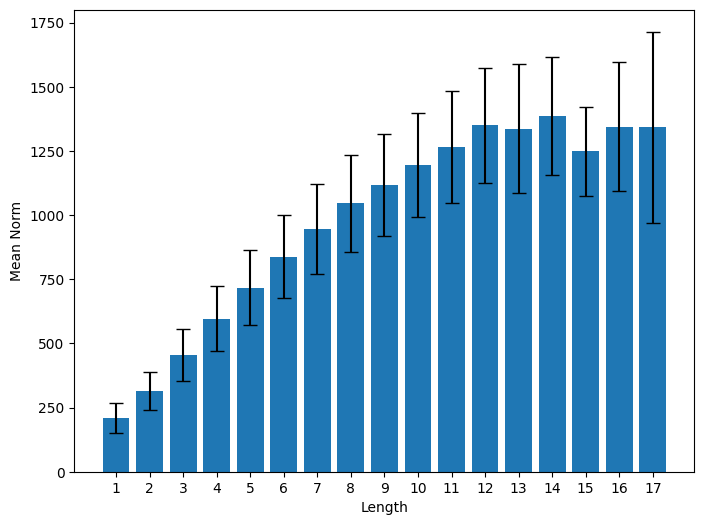

In [ ]:
df = pd.read_csv("data/train.csv", index_col=0, converters=converters)
df["Norm"] = df["H1"].apply(lambda x: np.exp(np.linalg.norm(x)))

# Group by 'Length' and compute mean, standard deviation and count of Norm.
group_stats = df.groupby("Length")["Norm"].agg(["mean", "std", "count"]).reset_index()

# Compute the standard error of the mean (SEM)
group_stats["sem"] = group_stats["std"] / np.sqrt(group_stats["count"])

print(group_stats)

# Create the bar plot with error bars.
plt.figure(figsize=(8, 6))
plt.bar(group_stats["Length"], group_stats["mean"], yerr=group_stats["std"], capsize=5)
plt.xlabel("Length")
plt.ylabel("Mean Norm")
plt.xticks(group_stats["Length"])
plt.show()

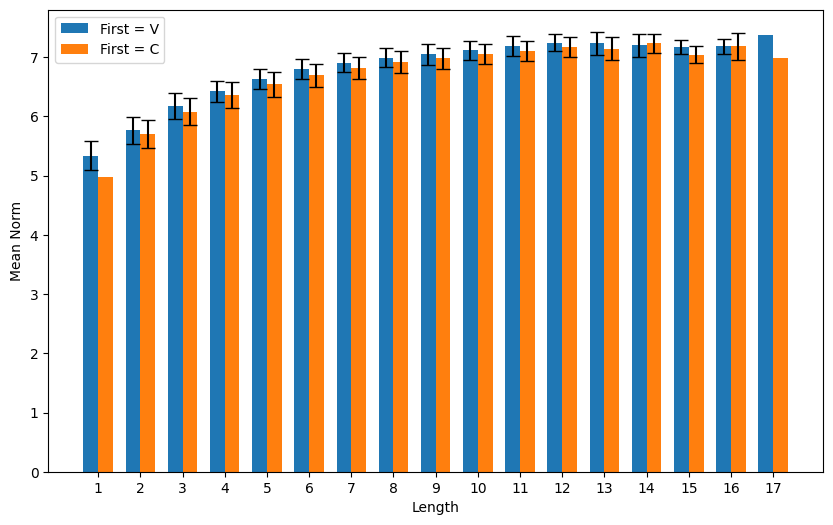

In [ ]:
# Load the data with your converters
df = pd.read_csv("data/train.csv", index_col=0, converters=converters)
df["Norm"] = df["H1"].apply(lambda x: np.linalg.norm(x))

# Group by both 'Length' and 'First' and compute mean, std, and count for 'Norm'.
group_stats = (
    df.groupby(["Length", "First"])["Norm"].agg(["mean", "std", "count"]).reset_index()
)

# Compute the standard error of the mean (SEM)
group_stats["sem"] = group_stats["std"] / np.sqrt(group_stats["count"])

# Determine unique lengths (x-axis groups) and sort them.
unique_lengths = sorted(group_stats["Length"].unique())

# Determine the categories for the 'First' column.
# Adjust ordering if necessary. For example, if you want V to appear first:
unique_first = ["V", "C"]

# Parameters for grouped bar plot
bar_width = 0.35
x = np.arange(len(unique_lengths))

fig, ax = plt.subplots(figsize=(10, 6))

# Loop over the two groups to plot each bar with an offset.
for i, first_val in enumerate(unique_first):
    # Filter group_stats for the current 'First' category.
    subset = group_stats[group_stats["First"] == first_val].set_index("Length")

    # For each length, get the mean and SEM (or NaN if that combination is missing)
    means = [
        subset.loc[length]["mean"] if length in subset.index else np.nan
        for length in unique_lengths
    ]
    sems = [
        subset.loc[length]["std"] if length in subset.index else np.nan
        for length in unique_lengths
    ]

    # Compute offset: centers the two bars around each x-tick.
    offset = (i - (len(unique_first) - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        means,
        width=bar_width,
        yerr=sems,
        capsize=5,
        label=f"First = {first_val}",
    )

# Set the x-axis ticks to the unique Length values.
ax.set_xticks(x)
ax.set_xticklabels(unique_lengths)
ax.set_xlabel("Length")
ax.set_ylabel("Mean Norm")
ax.legend()
plt.show()

In [ ]:
# Load the data with your converters
df = pd.read_csv("data/train.csv", index_col=0, converters=converters)


# Define a function to compute mean cosine distance and its standard deviation for a given group.
def compute_cosine_stats(group):
    emb = np.array(group["H1"].tolist())
    dist = pdist(emb, metric="cosine")
    return pd.Series({"mean_cosine": dist.mean(), "std_cosine": dist.std()})


# Group by both 'Length' and 'First' then apply the function.
group_stats = df.groupby(["Length", "First"]).apply(compute_cosine_stats).reset_index()

# Determine the unique length groups for the x-axis.
unique_lengths = sorted(group_stats["Length"].unique())

# Specify the order for the 'First' groups (e.g., V and C).
unique_first = ["V", "C"]

# Parameters for the grouped bar plot.
bar_width = 0.35
x = np.arange(len(unique_lengths))

fig, ax = plt.subplots(figsize=(10, 6))

# Loop over each 'First' group and plot the corresponding bars.
for i, first_val in enumerate(unique_first):
    # Filter for the current 'First' group.
    subset = group_stats[group_stats["First"] == first_val].set_index("Length")
    # Create lists of mean cosine distances and their standard deviations for each unique length.
    means = [
        subset.loc[length]["mean_cosine"] if length in subset.index else np.nan
        for length in unique_lengths
    ]
    stds = [
        subset.loc[length]["std_cosine"] if length in subset.index else np.nan
        for length in unique_lengths
    ]

    # Calculate offset so that the two bars appear side by side.
    offset = (i - (len(unique_first) - 1) / 2) * bar_width
    ax.bar(
        x + offset,
        means,
        width=bar_width,
        yerr=stds,
        capsize=5,
        label=f"First = {first_val}",
    )

# Set the x-axis ticks to correspond exactly to the unique Length values.
ax.set_xticks(x)
ax.set_xticklabels(unique_lengths)
ax.set_xlabel("Length")
ax.set_ylabel("Mean Cosine Distance")
ax.legend()
plt.show()

In [ ]:
csv_path = "data/train_hidden.csv"
df = pd.read_csv(csv_path, index_col=0, converters=converters)

npy_path = "data/train_hidden.npy"
emb = np.load(npy_path)

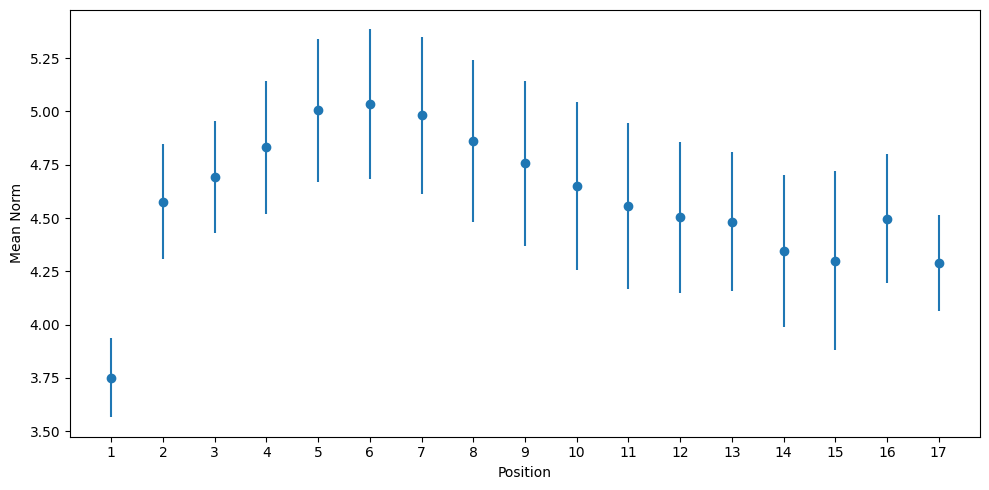

In [ ]:
def norm_by_position(df: pd.DataFrame, emb: np.ndarray) -> None:
    """Calculate average norm of the deltas of the embeddings by position."""

    max_length = df["Length"].max()
    positions = range(1, max_length + 1)
    data = {pos: [] for pos in positions}

    # iterate through the dataframe
    for i, row in df.iterrows():
        length = row["Length"]
        prev = np.zeros(emb.shape[2])
        for pos in range(length):
            curr = emb[i, pos, :]  # type: ignore
            delta = curr - prev
            data[pos + 1].append(np.linalg.norm(delta))
            prev = curr

    # # print the size of the data
    # for pos, norms in data.items():
    #     print(f"Position {pos}: {len(norms)} deltas")

    # calculate the average deltas
    means = [np.mean(norms) for norms in data.values()]
    stds = [np.std(norms) for norms in data.values()]

    # plot the results
    plt.figure(figsize=(10, 5))
    plt.errorbar(positions, means, yerr=stds, fmt="o")
    plt.xlabel("Position")
    plt.ylabel("Mean Norm")
    plt.xticks(positions)
    plt.tight_layout()
    plt.show()


norm_by_position(df, emb)

/var/folders/lq/gkdcr_9s1qq4jxv0w46k1jg40000gn/T/ipykernel_1398/2154821816.py:22: RuntimeWarning: invalid value encountered in scalar divide
  sim = np.dot(p, d) / (np.linalg.norm(p) * np.linalg.norm(d))


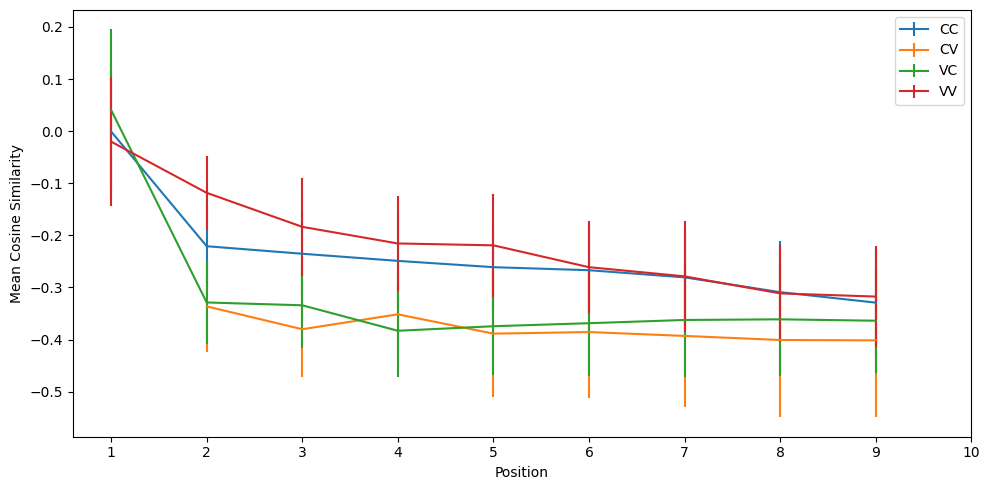

In [ ]:
def cossim_by_position(df: pd.DataFrame, emb: np.ndarray) -> None:
    """Line plot with mean cosine similarity at each position for each bigram type."""
    df = df[df["Length"] > 1].copy()

    # max_len = df["Length"].max()
    max_len = 10
    types = ["CC", "CV", "VC", "VV"]
    posit = range(1, max_len + 1)
    data = {t: {j: [] for j in posit} for t in types}

    # iterate through the dataframe
    p = np.zeros(emb.shape[2])
    for i, row in df.iterrows():
        for j in range(1, min(row["Length"], max_len)):
            t1 = "V" if row["No_Stress"][j - 1] in vowels else "C"
            t2 = "V" if row["No_Stress"][j] in vowels else "C"

            a = emb[i, j - 1, :]  # type: ignore
            b = emb[i, j, :]  # type: ignore
            # sim = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
            d = a - b
            sim = np.dot(p, d) / (np.linalg.norm(p) * np.linalg.norm(d))
            p = d

            data[t1 + t2][j].append(sim)

    # calculate the average deltas
    means = {
        t: [np.mean(data[t][j]) if len(data[t][j]) > 0 else np.nan for j in posit]
        for t in types
    }
    stds = {
        t: [np.std(data[t][j]) if len(data[t][j]) > 0 else np.nan for j in posit]
        for t in types
    }

    # plot the results
    plt.figure(figsize=(10, 5))
    for t in types:
        plt.errorbar(posit, means[t], yerr=stds[t], label=t)  # type: ignore
        # plt.plot(posit, means[t], label=t)
    plt.xlabel("Position")
    plt.ylabel("Mean Cosine Similarity")
    plt.xticks(posit)
    plt.legend()
    plt.tight_layout()
    plt.show()


cossim_by_position(df, emb)

In [ ]:
df_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1~b2048_l0.001_fall_sn/epochs/75/control/evaluation.csv"
df = pd.read_csv(df_path, index_col=0, converters=converters)

h_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1~b2048_l0.001_fall_sn/epochs/75/control/evaluation_h.npy"
h_emb = np.load(h_path)
print(h_emb.shape)

c_path = "../results/evaluation/Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1~b2048_l0.001_fall_sn/epochs/75/control/evaluation_c.npy"
c_emb = np.load(c_path)
print(c_emb.shape)

(1200, 20, 128)
(1200, 128)


In [ ]:
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

batch_size = h_emb.shape[0]
num_neurons = c_emb.shape[1]

# get array of lengths from the dataframe
lengths = df["Length"].to_numpy()

# use to extract only the h from the final time step
h_emb1 = h_emb[np.arange(batch_size), lengths, :]

h_data = {"Neuron": [], "Feature": [], "Importance": [], "Spearman": []}
c_data = {"Neuron": [], "Feature": [], "Importance": [], "Spearman": []}

# for emb, data in [(h_emb1, h_data), (c_emb, c_data)]:

for emb, data in [(h_emb1, h_data)]:

    continuous = ["Length"]
    categorical = ["Lexicality", "Morphology"]
    features = continuous + categorical

    preprocessor = ColumnTransformer(
        transformers=[
            ("con", StandardScaler(), continuous),
            ("cat", OneHotEncoder(drop="first"), categorical),
        ]
    )
    pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", Ridge())])
    X = df[continuous + categorical].copy()

    for idx in range(num_neurons):
        print(f"Calculating importance for neuron {idx+1}...  ", end="\r")
        y = emb[:, idx]
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        pipeline.fit(X_train, y_train)
        result = permutation_importance(
            pipeline,
            X_test,
            y_test,
            n_repeats=100,
            random_state=42,
        )
        coefficients = pipeline.named_steps["regressor"].coef_
        importances = result.importances_mean  # * np.sign(coefficients)  # type: ignore
        y_pred = pipeline.predict(X_test)
        rho, _ = spearmanr(y_test, y_pred)

        for i, feature in enumerate(features):
            data["Neuron"].append(idx)
            data["Feature"].append(feature)
            data["Importance"].append(importances[i])
            data["Spearman"].append(rho)

df_h = pd.DataFrame(h_data)
# df_c = pd.DataFrame(c_data)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def find_best_n_clusters(df, max_clusters=10, seed=42):
    """Finds the optimal number of clusters for the points in `df` using KMeans and the silhouette method.

    Parameters
    ----------
    df : pandas dataframe
        Dataframe of points to cluster
    max_clusters : int, default=6
        Maximum number of clusters
    seed : int, default=0
        Random seed for reproducibility

    Returns
    -------
    best_num_clusters: int
        Optimal number of clusters
    clusters: array
        Cluster labels for each point
    """

    best_num_clusters = 0
    best_silhouette_score = -1
    for num_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=num_clusters, random_state=seed)
        labels = kmeans.fit_predict(df)
        silhouette_avg = silhouette_score(df, labels)

        if silhouette_avg > best_silhouette_score:
            best_silhouette_score = silhouette_avg
            best_num_clusters = num_clusters

    kmeans = KMeans(n_clusters=best_num_clusters, random_state=seed)
    clusters = kmeans.fit_predict(df)

    return best_num_clusters, clusters

In [ ]:
b = df_h.copy()

b["Importance"] = np.sign(b["Importance"]) * np.log1p(np.abs(b["Importance"]))
# b["Spearman"] = np.clip(b["Spearman"], 0, None)
# b["Importance"] = b["Importance"] / b["Spearman"]

a = df_h.pivot_table(index="Neuron", columns="Feature", values="Importance")
best_num_clusters, clusters = find_best_n_clusters(a, max_clusters=8)
print(f"Optimal number of clusters: {best_num_clusters}")

a["Cluster"] = clusters
a = a.reset_index().rename(columns={"index": "Neuron"})
b = b.merge(a[["Neuron", "Cluster"]], on="Neuron")
b

Optimal number of clusters: 2


,Neuron,Feature,Importance,Spearman,Cluster
0,0,Length,-0.014196,-0.065730,1
1,0,Lexicality,-0.000234,-0.065730,1
2,0,Morphology,0.001018,-0.065730,1
3,1,Length,0.179843,0.371658,1
4,1,Lexicality,0.000834,0.371658,1
5,1,Morphology,0.001448,0.371658,1
6,2,Length,0.001062,0.000190,1
7,2,Lexicality,-0.000101,0.000190,1
8,2,Morphology,0.000496,0.000190,1
9,3,Length,0.005017,-0.001026,1


     Neuron     Feature  Importance  Spearman  Cluster  cum_importance  \
334     111  Lexicality    0.000168  0.802212        0        0.743176   
335     111  Morphology    0.001367  0.802212        0        0.743009   
333     111      Length    0.741641  0.802212        0        0.741641   
362     120  Morphology    0.007837  0.676216        0        0.723641   
361     120  Lexicality    0.000000  0.676216        0        0.723641   
360     120      Length    0.715804  0.676216        0        0.715804   
148      49  Lexicality    0.003313  0.863546        0        0.704181   
149      49  Morphology    0.008799  0.863546        0        0.700868   
147      49      Length    0.692069  0.863546        0        0.692069   
50       16  Morphology    0.000315  0.690570        0        0.633265   
49       16  Lexicality    0.000000  0.690570        0        0.633265   
48       16      Length    0.632951  0.690570        0        0.632951   
67       22  Lexicality    0.006539  0

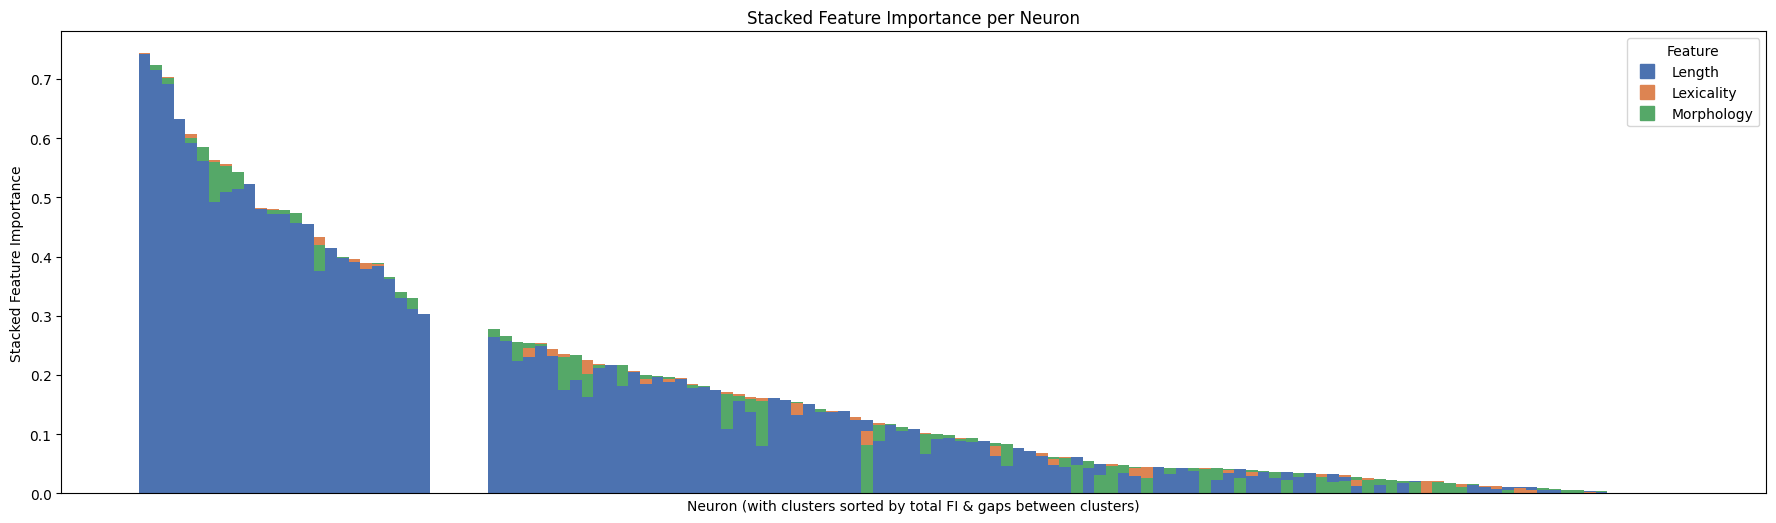

In [ ]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import seaborn as sns

df_m = b.copy()

# ---------------------------
# Step 1: Remove negative importance values by clipping at zero.
df_m["Importance"] = df_m["Importance"].clip(lower=0)
# Optionally, you can also normalize the importance values if needed
# df_m['Importance'] = df_m['Importance'] / df_m["Spearman"].abs().max()

# ---------------------------
# Step 2: Compute cumulative sums per neuron for stacking
# Within each neuron, sort the rows descending by importance (optional, adjust as needed)
df_m = df_m.sort_values(["Neuron", "Importance"], ascending=[True, False])
df_m["cum_importance"] = df_m.groupby("Neuron")["Importance"].cumsum()
df_m["bottom"] = df_m["cum_importance"] - df_m["Importance"]

print(df_m.sort_values("cum_importance", ascending=False).head(30))

# ---------------------------
# Step 3: Compute total importance per neuron.
neuron_totals = (
    df_m.groupby("Neuron")["Importance"]
    .sum()
    .reset_index()
    .rename(columns={"Importance": "total_importance"})
)

# ---------------------------
# Step 4: Get unique neuron-level info (Neuron and Cluster) and merge totals.
neurons = df_m[["Neuron", "Cluster"]].drop_duplicates().reset_index(drop=True)
neurons = neurons.merge(neuron_totals, on="Neuron", how="left")

# ---------------------------
# Step 5: Compute total importance per cluster and sort clusters descending.
cluster_totals = neurons.groupby("Cluster")["total_importance"].sum().reset_index()
cluster_totals = cluster_totals.sort_values(
    "total_importance", ascending=False
).reset_index(drop=True)

# Create a mapping from the original Cluster to a new cluster order
cluster_order_map = {
    old: new for new, old in enumerate(cluster_totals["Cluster"], start=1)
}
neurons["new_cluster"] = neurons["Cluster"].map(cluster_order_map)

# ---------------------------
# Step 6: Sort neurons by new cluster order and then by total importance (or neuron id)
neurons = neurons.sort_values(
    ["new_cluster", "total_importance"], ascending=[True, False]
).reset_index(drop=True)
neurons["within_cluster_order"] = neurons.groupby("new_cluster").cumcount()

# ---------------------------
# Step 7: Define a custom x-axis (unit_index) with gaps between clusters.
gap_size = 5  # adjust gap size as needed
offset_map = {}
current_offset = 0
for cl in sorted(neurons["new_cluster"].unique()):
    offset_map[cl] = current_offset
    count_in_cluster = neurons[neurons["new_cluster"] == cl].shape[0]
    current_offset += count_in_cluster + gap_size

neurons["unit_index"] = neurons["within_cluster_order"] + neurons["new_cluster"].map(
    offset_map
)

# ---------------------------
# Step 8: Merge the custom unit_index back into the melted DataFrame.
df_m = df_m.merge(neurons[["Neuron", "unit_index"]], on="Neuron", how="left")

# ---------------------------
# Step 9: Plot the stacked bars.
plt.figure(figsize=(22, 6))
ax = plt.gca()

# Use Seaborn's default "deep" palette for our features.
features = sorted(df_m["Feature"].unique())
palette = dict(zip(features, sns.color_palette("deep", len(features))))

# Draw each segment as a bar segment.
for _, row in df_m.iterrows():
    ax.bar(
        row["unit_index"],
        row["Importance"],
        bottom=row["bottom"],
        width=1,
        color=palette.get(row["Feature"], "gray"),
    )

ax.set_xlabel("Neuron (with clusters sorted by total FI & gaps between clusters)")
ax.set_ylabel("Stacked Feature Importance")
ax.set_title("Stacked Feature Importance per Neuron")
plt.xticks([])  # Optionally hide x-tick labels

handles = [
    mlines.Line2D(
        [],
        [],
        color=palette[feat],
        marker="s",
        linestyle="None",
        markersize=10,
        label=feat,
    )
    for feat in features
]
plt.legend(handles=handles, title="Feature", loc="upper right")
plt.show()